In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits, ascii
from astropy.table import Table
from astropy.coordinates import SkyCoord

In [131]:
plt.rcParams['font.family'] = 'sans-serif' 
plt.style.use('default')
#specifies arial as the preferred font for plots
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['axes.titlesize'] = 14  # font size for plot titles
plt.rcParams['axes.labelsize'] = 12  # font size for x and y axis labels
plt.rcParams['xtick.labelsize'] = 10 # font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 10 # font size for y-axis tick labels
plt.rcParams['legend.fontsize'] = 10 # font size for legend
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['ytick.major.size'] = 10

In [132]:
table = Table.read('DR19seisages_samp_train456789_net10_method14151617_cluster1819_v2.fits.zip', format='fits')
valid_colnames = [name for name in table.colnames if len(table[name].shape) <= 1]
filtered_table = table[valid_colnames]
data = filtered_table.to_pandas()

In [133]:
table.columns

<TableColumns names=('sdss_id','sdss4_apogee_id','gaia_dr2_source_id','gaia_dr3_source_id','tic_v8_id','healpix','lead','version_id','catalogid','catalogid21','catalogid25','catalogid31','n_associated','n_neighborhood','sdss5_target_flags','sdss4_apogee_target1_flags','sdss4_apogee_target2_flags','sdss4_apogee2_target1_flags','sdss4_apogee2_target2_flags','sdss4_apogee2_target3_flags','sdss4_apogee_member_flags','sdss4_apogee_extra_target_flags','ra','dec','l','b','plx','e_plx','pmra','e_pmra','pmde','e_pmde','gaia_v_rad','gaia_e_v_rad','g_mag','bp_mag','rp_mag','j_mag','e_j_mag','h_mag','e_h_mag','k_mag','e_k_mag','ph_qual','bl_flg','cc_flg','w1_mag','e_w1_mag','w1_flux','w1_dflux','w1_frac','w2_mag','e_w2_mag','w2_flux','w2_dflux','w2_frac','w1uflags','w2uflags','w1aflags','w2aflags','mag4_5','d4_5m','rms_f4_5','sqf_4_5','mf4_5','csf','zgr_teff','zgr_e_teff','zgr_logg','zgr_e_logg','zgr_fe_h','zgr_e_fe_h','zgr_e','zgr_e_e','zgr_plx','zgr_e_plx','zgr_teff_confidence','zgr_logg_confide

In [134]:
feh_col = "fe_h"
c_col   = "c_h"
n_col   = "n_h"

good = np.isfinite(data[feh_col]) & (data[feh_col] != -9999) & np.isfinite(data[c_col])   & (data[c_col]   != -9999) & np.isfinite(data[n_col])   & (data[n_col]   != -9999)

In [135]:
data = data[good]

In [136]:
good_tess_ages = (data['JM_TESS_Net1_Age'] != -9999) & (data['JM_TESS_Net2_Age'] != -9999)
data_tess = data[good_tess_ages]

In [137]:
o_clusters = data_tess['OpenCluster_Name'] != b'-9999'
g_clusters = data_tess['GlobularCluster_Name'] != b'-9999'

In [138]:
o_cluster_stars = data_tess[o_clusters]
g_cluster_stars = data_tess[g_clusters]

In [139]:
o_cluster_stars

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,Cluster_CG20_Age,Cluster_HR23_Age,GlobularCluster_Name,Cluster_D07_Age,JM_TESS_Net1_Age,JM_TESS_Net2_Age,Miglio2021_Age,Leung2023_Age,Mackereth2019_Age,StoneMartinez2025_Age
3433,73625316,b'-9999',3030262468592291072,3030262468592291072,288474555,121762,b'tic_v8',21,4466167630,4466167630,...,1.096478,1.174898,b'-9999',-9999.0,1.393170,1.493626,-9999.0,-9999.000000,-9999.000000,-9999.000000
3448,73634113,b'-9999',3030730345148235648,3030730345148235648,259446813,120738,b'tic_v8',21,4466222439,4466222439,...,1.096478,1.174898,b'-9999',-9999.0,1.540033,1.462495,-9999.0,-9999.000000,-9999.000000,-9999.000000
3579,73698121,b'-9999',3033962462656438144,3033962462656438144,288480341,118690,b'tic_v8',21,4476587456,4476587456,...,0.977237,1.288250,b'-9999',-9999.0,2.900353,1.870114,-9999.0,-9999.000000,-9999.000000,-9999.000000
4536,115649965,b'-9999',184098005005159808,184098005005159808,367845024,40308,b'tic_v8',21,4514161728,4514161728,...,2.570396,1.047129,b'-9999',-9999.0,3.419637,3.319441,-9999.0,-9999.000000,-9999.000000,-9999.000000
5564,77077614,b'-9999',3376873682357153408,3376873682357153408,46046420,61829,b'tic_v8',21,4538255649,4538255649,...,0.562341,0.181970,b'-9999',-9999.0,1.821113,1.746468,-9999.0,-9999.000000,-9999.000000,-9999.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379938,116255363,b'2M03590443+5148003',250930925948393088,250930925948393088,265757257,21080,b'gaia_dr3_source',31,63050396574211337,4331931455,...,0.223872,0.190546,b'-9999',-9999.0,1.841348,3.275250,-9999.0,-9999.000000,0.334219,0.000000
379939,116255383,b'2M03592828+5148425',250931127806592640,250931127806592640,265879328,21080,b'gaia_dr3_source',31,63050396574211476,4331931978,...,0.223872,0.190546,b'-9999',-9999.0,2.065208,1.528593,-9999.0,-9999.000000,-9999.000000,0.000000
384831,116885668,b'2M01582981+3751374',342893803614055168,342893803614055168,67520261,37674,b'gaia_dr3_source',31,63050396584297004,4407284419,...,1.174898,1.412538,b'-9999',-9999.0,1.587474,1.312065,-9999.0,0.878665,-9999.000000,1.066132
384872,116887419,b'2M01552765+3759551',343118619382072832,343118619382072832,67420118,37161,b'gaia_dr3_source',31,63050396584310854,4407254997,...,1.174898,1.412538,b'-9999',-9999.0,1.202259,1.249886,-9999.0,0.874839,-9999.000000,0.785571


# Cantat-Gaudin 2020

In [159]:
data_oclusters_net1 = o_cluster_stars.groupby('OpenCluster_Name', as_index=False).agg({
    'JM_TESS_Net1_Age': ['mean', 'std'],
    'Cluster_CG20_Age': 'median'})
data_oclusters_net1 = data_oclusters_net1.dropna()
print(data_oclusters_net1)

    OpenCluster_Name JM_TESS_Net1_Age           Cluster_CG20_Age
                                 mean       std           median
0          b'BH_211'         1.874091  0.342172         0.426580
1     b'Berkeley_10'         1.235278  0.467304         1.202264
2     b'Berkeley_13'         1.133973  0.078081         0.489779
3     b'Berkeley_17'         6.306750  0.396423         7.244360
4     b'Berkeley_18'         3.832512  0.423419         4.365158
..               ...              ...       ...              ...
106    b'Teutsch_51'         2.157769  0.744054         0.676083
108    b'Tombaugh_2'         3.553181  0.670289         1.621810
110   b'Trumpler_20'         1.704257  0.328097         1.862087
111   b'Trumpler_26'         1.806586  0.667494         0.251189
112    b'Trumpler_5'         4.145274  0.409607         4.265795

[66 rows x 4 columns]


In [160]:
ocluster_net1_dispersion_cg20 = (o_cluster_stars['JM_TESS_Net1_Age'] - o_cluster_stars['Cluster_CG20_Age']) / o_cluster_stars['Cluster_CG20_Age']
ocluster_net1_meandisp_cg20 = (data_oclusters_net1['JM_TESS_Net1_Age']['mean'] - data_oclusters_net1['Cluster_CG20_Age']['median']) / data_oclusters_net1['Cluster_CG20_Age']['median']

Text(0.5, 0.98, 'Cantat-Gaudin 2020 Dispersion Network 1')

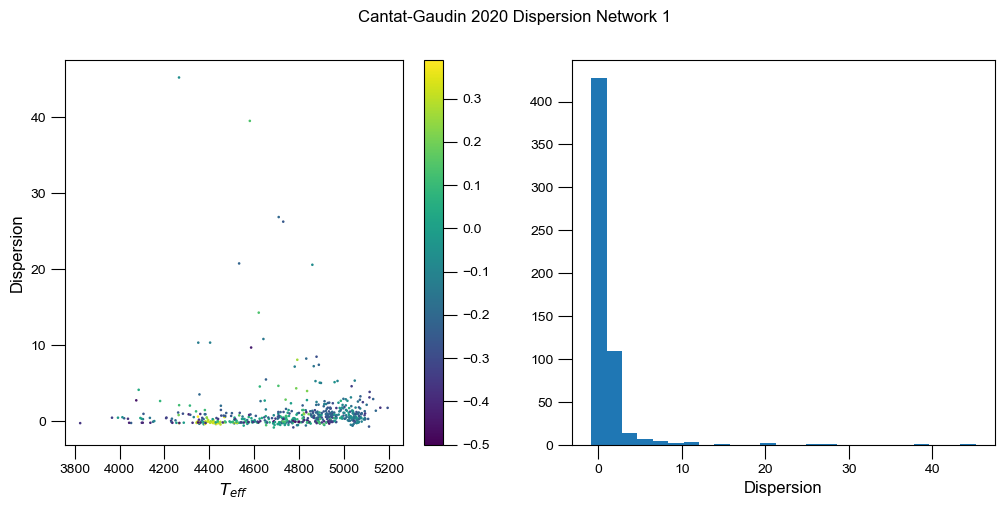

In [161]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.scatter(o_cluster_stars['teff'], ocluster_net1_dispersion_cg20, s=0.75, c=o_cluster_stars['fe_h'])
ax1.set_xlabel('$T_{eff}$')
ax1.set_ylabel('Dispersion')
fig.colorbar(im)
ax2.hist(ocluster_net1_dispersion_cg20, bins=25)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('Cantat-Gaudin 2020 Dispersion Network 1')

Text(0.5, 0.98, 'Cantat-Gaudin 2020 Mean Dispersion Network 1')

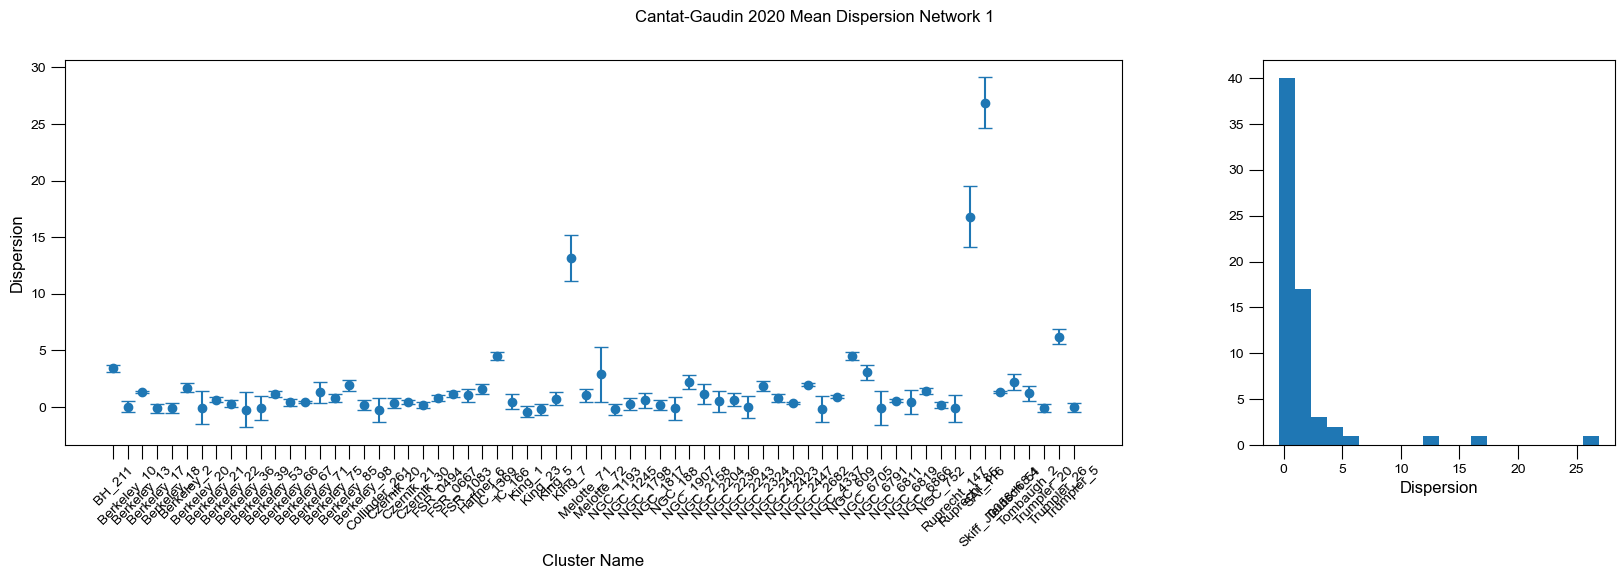

In [162]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [3, 1]})
im = ax1.errorbar(data_oclusters_net1['OpenCluster_Name'], ocluster_net1_meandisp_cg20, yerr=data_oclusters_net1['JM_TESS_Net1_Age']['std'], fmt='o', capsize=5)
ax1.set_xlabel('Cluster Name')
ax1.set_ylabel('Dispersion')
ax1.tick_params(axis='x', rotation=45)
ax2.hist(ocluster_net1_meandisp_cg20, bins=20)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('Cantat-Gaudin 2020 Mean Dispersion Network 1')

In [163]:
data_oclusters_net2 = o_cluster_stars.groupby('OpenCluster_Name', as_index=False).agg({
    'JM_TESS_Net2_Age': ['mean', 'std'],
    'Cluster_CG20_Age': 'median'})
data_oclusters_net2 = data_oclusters_net2.dropna()
print(data_oclusters_net2)

    OpenCluster_Name JM_TESS_Net2_Age           Cluster_CG20_Age
                                 mean       std           median
0          b'BH_211'         1.827258  0.110711         0.426580
1     b'Berkeley_10'         2.048595  1.308728         1.202264
2     b'Berkeley_13'         1.658841  0.104798         0.489779
3     b'Berkeley_17'         6.051188  0.312085         7.244360
4     b'Berkeley_18'         4.051543  0.507544         4.365158
..               ...              ...       ...              ...
106    b'Teutsch_51'         2.173676  0.377704         0.676083
108    b'Tombaugh_2'         3.243409  1.018937         1.621810
110   b'Trumpler_20'         1.761849  0.537958         1.862087
111   b'Trumpler_26'         1.629137  0.398411         0.251189
112    b'Trumpler_5'         4.112148  0.507483         4.265795

[66 rows x 4 columns]


In [164]:
ocluster_net2_dispersion_cg20 = (o_cluster_stars['JM_TESS_Net2_Age'] - o_cluster_stars['Cluster_CG20_Age']) / o_cluster_stars['Cluster_CG20_Age']
ocluster_net2_meandisp_cg20 = (data_oclusters_net2['JM_TESS_Net2_Age']['mean'] - data_oclusters_net2['Cluster_CG20_Age']['median']) / data_oclusters_net2['Cluster_CG20_Age']['median']

Text(0.5, 0.98, 'Cantat-Gaudin 2020 Dispersion Network 2')

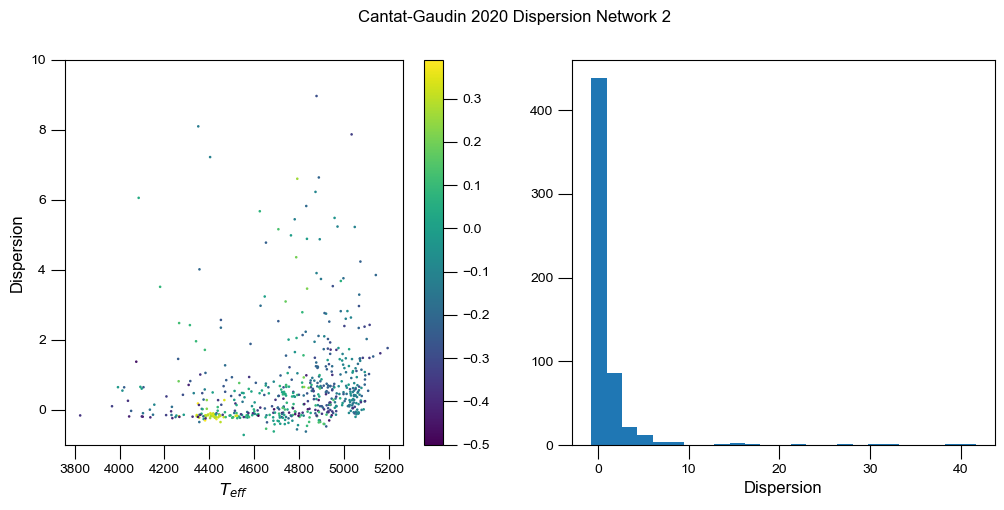

In [165]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.scatter(o_cluster_stars['teff'], ocluster_net2_dispersion_cg20, s=0.75, c=o_cluster_stars['fe_h'])
ax1.set_xlabel('$T_{eff}$')
ax1.set_ylabel('Dispersion')
ax1.set_ylim(-1,10)
fig.colorbar(im)
ax2.hist(ocluster_net2_dispersion_cg20, bins=25)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('Cantat-Gaudin 2020 Dispersion Network 2')

Text(0.5, 0.98, 'Cantat-Gaudin 2020 Mean Dispersion Network 2')

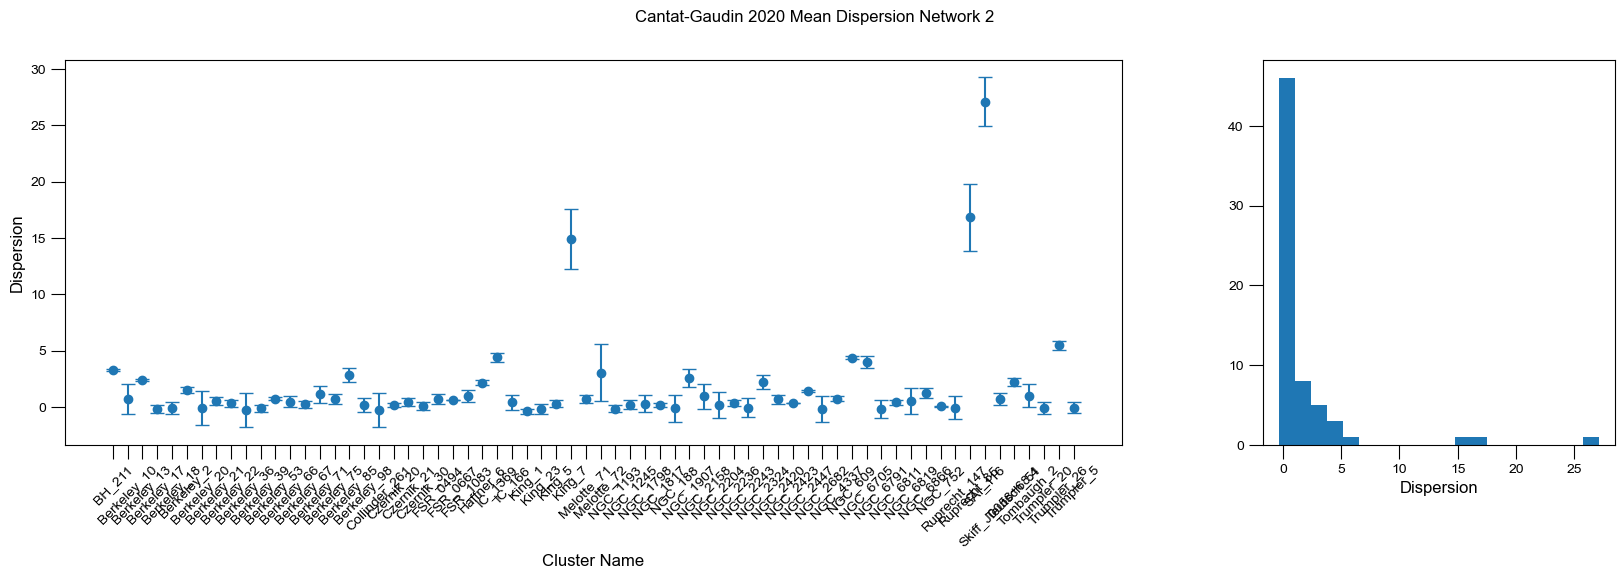

In [167]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [3, 1]})
im = ax1.errorbar(data_oclusters_net2['OpenCluster_Name'], ocluster_net2_meandisp_cg20, yerr=data_oclusters_net2['JM_TESS_Net2_Age']['std'], fmt='o', capsize=5)
ax1.set_xlabel('Cluster Name')
ax1.set_xlabel('Cluster Name')
ax1.set_ylabel('Dispersion')
ax1.tick_params(axis='x', rotation=45)
ax2.hist(ocluster_net2_meandisp_cg20, bins=20)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('Cantat-Gaudin 2020 Mean Dispersion Network 2')

# H, R et al. 2023

In [168]:
data_oclusters_net1 = o_cluster_stars.groupby('OpenCluster_Name', as_index=False).agg({
    'JM_TESS_Net1_Age': ['mean', 'std'],
    'Cluster_HR23_Age': 'median'})
data_oclusters_net1 = data_oclusters_net1.dropna()
print(data_oclusters_net1)

    OpenCluster_Name JM_TESS_Net1_Age           Cluster_HR23_Age
                                 mean       std           median
0          b'BH_211'         1.874091  0.342172         0.169824
1     b'Berkeley_10'         1.235278  0.467304         0.338844
2     b'Berkeley_13'         1.133973  0.078081         0.457088
3     b'Berkeley_17'         6.306750  0.396423         3.311311
4     b'Berkeley_18'         3.832512  0.423419         1.445440
..               ...              ...       ...              ...
106    b'Teutsch_51'         2.157769  0.744054         0.758578
108    b'Tombaugh_2'         3.553181  0.670289         1.698244
110   b'Trumpler_20'         1.704257  0.328097         1.584893
111   b'Trumpler_26'         1.806586  0.667494         0.194984
112    b'Trumpler_5'         4.145274  0.409607         2.187762

[66 rows x 4 columns]


In [169]:
ocluster_net1_dispersion_hr23 = (o_cluster_stars['JM_TESS_Net1_Age'] - o_cluster_stars['Cluster_HR23_Age']) / o_cluster_stars['Cluster_HR23_Age']
ocluster_net1_meandisp_hr23 = (data_oclusters_net1['JM_TESS_Net1_Age']['mean'] - data_oclusters_net1['Cluster_HR23_Age']['median']) / data_oclusters_net1['Cluster_HR23_Age']['median']

Text(0.5, 0.98, 'HR 23 Dispersion Network 1')

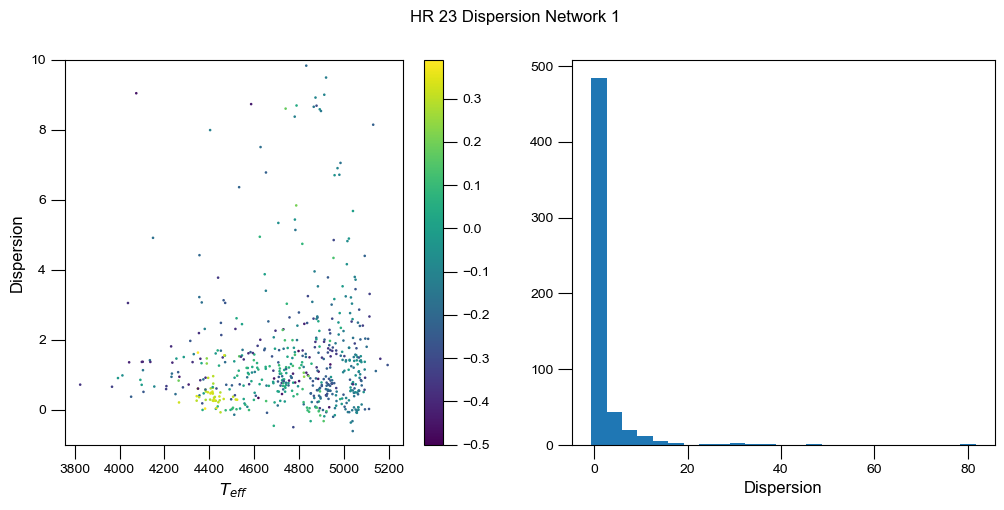

In [170]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.scatter(o_cluster_stars['teff'], ocluster_net1_dispersion_hr23, s=0.75, c=o_cluster_stars['fe_h'])
ax1.set_xlabel('$T_{eff}$')
ax1.set_ylabel('Dispersion')
ax1.set_ylim(-1,10)
fig.colorbar(im)
ax2.hist(ocluster_net1_dispersion_hr23, bins=25)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('HR 23 Dispersion Network 1')

Text(0.5, 0.98, 'HR 23 Mean Dispersion Network 1')

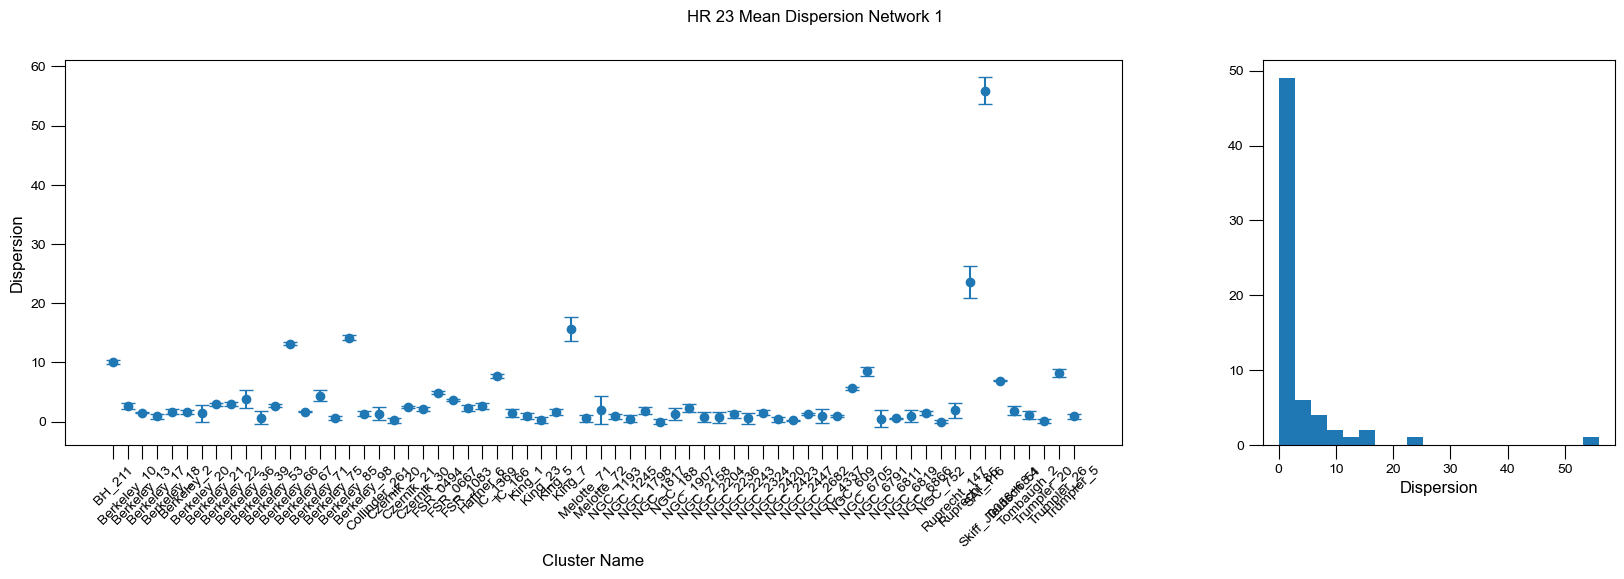

In [171]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [3, 1]})
im = ax1.errorbar(data_oclusters_net1['OpenCluster_Name'], ocluster_net1_meandisp_hr23, yerr=data_oclusters_net1['JM_TESS_Net1_Age']['std'], fmt='o', capsize=5)
ax1.set_xlabel('Cluster Name')
ax1.set_ylabel('Dispersion')
ax1.tick_params(axis='x', rotation=45)
ax2.hist(ocluster_net1_meandisp_hr23, bins=20)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('HR 23 Mean Dispersion Network 1')

In [172]:
data_oclusters_net2 = o_cluster_stars.groupby('OpenCluster_Name', as_index=False).agg({
    'JM_TESS_Net2_Age': ['mean', 'std'],
    'Cluster_HR23_Age': 'median'})
data_oclusters_net2 = data_oclusters_net2.dropna()
print(data_oclusters_net2)

    OpenCluster_Name JM_TESS_Net2_Age           Cluster_HR23_Age
                                 mean       std           median
0          b'BH_211'         1.827258  0.110711         0.169824
1     b'Berkeley_10'         2.048595  1.308728         0.338844
2     b'Berkeley_13'         1.658841  0.104798         0.457088
3     b'Berkeley_17'         6.051188  0.312085         3.311311
4     b'Berkeley_18'         4.051543  0.507544         1.445440
..               ...              ...       ...              ...
106    b'Teutsch_51'         2.173676  0.377704         0.758578
108    b'Tombaugh_2'         3.243409  1.018937         1.698244
110   b'Trumpler_20'         1.761849  0.537958         1.584893
111   b'Trumpler_26'         1.629137  0.398411         0.194984
112    b'Trumpler_5'         4.112148  0.507483         2.187762

[66 rows x 4 columns]


In [173]:
ocluster_net2_dispersion_hr23 = (o_cluster_stars['JM_TESS_Net2_Age'] - o_cluster_stars['Cluster_HR23_Age']) / o_cluster_stars['Cluster_HR23_Age']
ocluster_net2_meandisp_hr23 = (data_oclusters_net2['JM_TESS_Net2_Age']['mean'] - data_oclusters_net2['Cluster_HR23_Age']['median']) / data_oclusters_net2['Cluster_HR23_Age']['median']

Text(0.5, 0.98, 'HR 23 Dispersion Network 2')

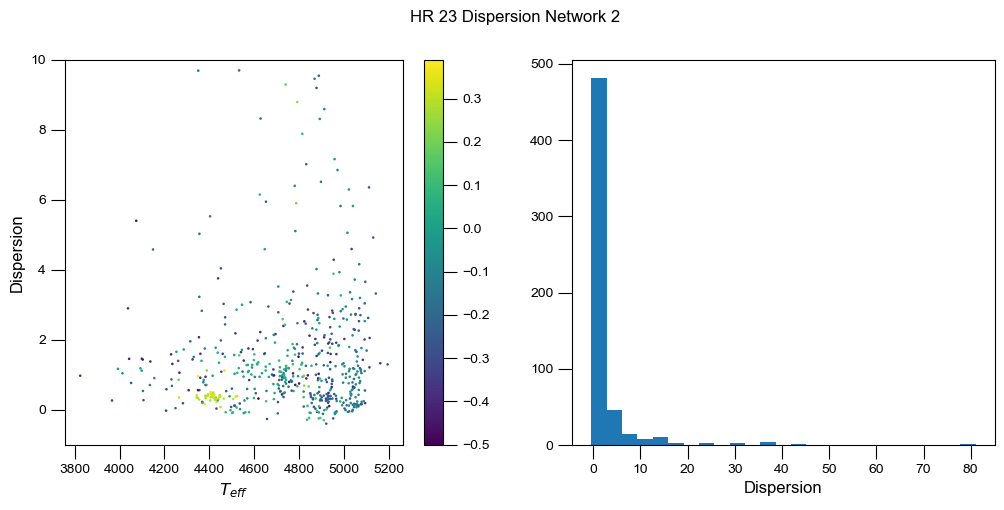

In [174]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.scatter(o_cluster_stars['teff'], ocluster_net2_dispersion_hr23, s=0.75, c=o_cluster_stars['fe_h'])
ax1.set_xlabel('$T_{eff}$')
ax1.set_ylabel('Dispersion')
ax1.set_ylim(-1,10)
fig.colorbar(im)
ax2.hist(ocluster_net2_dispersion_hr23, bins=25)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('HR 23 Dispersion Network 2')

Text(0.5, 0.98, 'HR 23 Mean Dispersion Network 2')

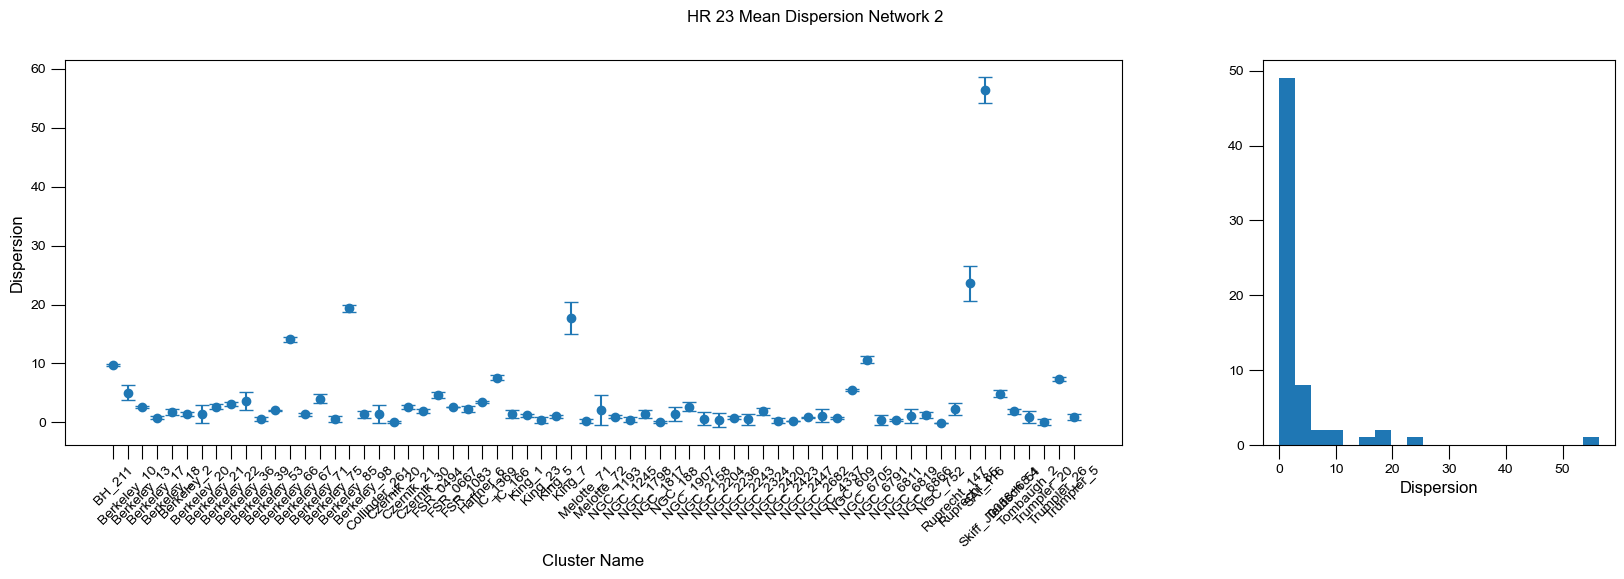

In [175]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [3, 1]})
im = ax1.errorbar(data_oclusters_net2['OpenCluster_Name'], ocluster_net2_meandisp_hr23, yerr=data_oclusters_net2['JM_TESS_Net2_Age']['std'], fmt='o', capsize=5)
ax1.set_xlabel('Cluster Name')
ax1.set_ylabel('Dispersion')
ax1.tick_params(axis='x', rotation=45)
ax2.hist(ocluster_net2_meandisp_hr23, bins=20)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('HR 23 Mean Dispersion Network 2')

# D 07

In [177]:
cluster_age_exists = g_cluster_stars['Cluster_D07_Age'] != -9999 # I guess some clusters don't have ages in this catalog
g_cluster_stars = g_cluster_stars[cluster_age_exists]

In [178]:
data_gclusters_net1 = g_cluster_stars.groupby('GlobularCluster_Name', as_index=False).agg({
    'JM_TESS_Net1_Age': ['mean', 'std'],
    'Cluster_D07_Age': 'median'})
data_gclusters_net1 = data_gclusters_net1.dropna()
print(data_gclusters_net1)

   GlobularCluster_Name JM_TESS_Net1_Age           Cluster_D07_Age
                                    mean       std          median
0            b'NGC0104'         4.249474  2.962714          12.960
1            b'NGC0288'         5.514627  3.168469          11.880
2            b'NGC0362'         2.983604  1.825047          11.340
3            b'NGC1851'         2.530696  2.122017          10.800
4            b'NGC2298'         2.198798  2.591397          13.635
5            b'NGC2808'         2.769111  2.188103          12.285
6            b'NGC3201'         4.617077  2.164769          11.610
7            b'NGC4590'         0.745008  1.252124          12.015
8            b'NGC5024'         2.939458  1.515049          13.635
9            b'NGC5139'         4.772178  3.027092          12.690
10           b'NGC5272'         4.000514  2.040786          12.960
11           b'NGC5466'         3.486901  2.342986          13.905
12           b'NGC5904'         3.002620  2.428624          11

In [179]:
gcluster_net1_dispersion_d07 = (g_cluster_stars['JM_TESS_Net1_Age'] - g_cluster_stars['Cluster_D07_Age']) / g_cluster_stars['Cluster_D07_Age']
gcluster_net1_meandisp_d07 = (data_gclusters_net1['JM_TESS_Net1_Age']['mean'] - data_gclusters_net1['Cluster_D07_Age']['median']) / data_gclusters_net1['Cluster_D07_Age']['median']

Text(0.5, 0.98, 'D 07 Dispersion Network 1')

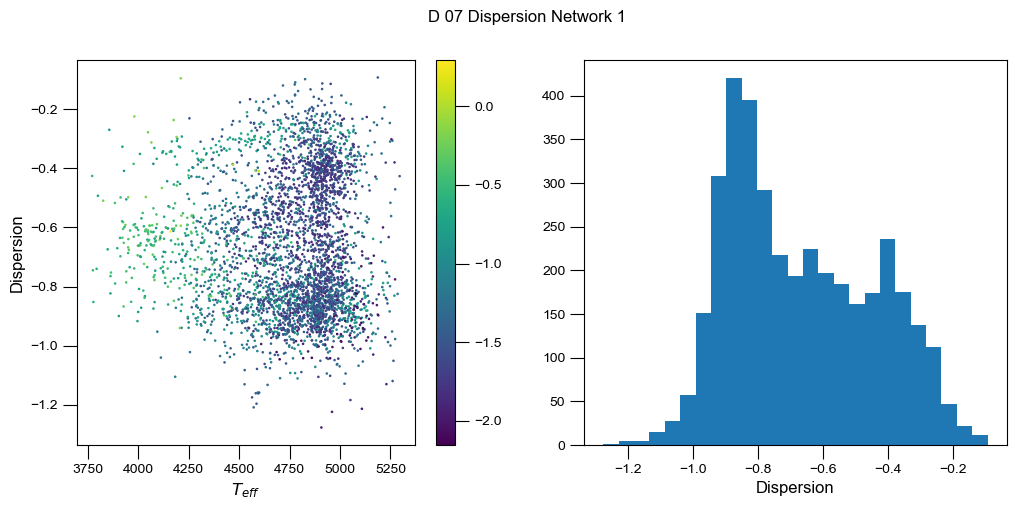

In [181]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.scatter(g_cluster_stars['teff'], gcluster_net1_dispersion_d07, s=0.75, c=g_cluster_stars['fe_h'])
ax1.set_xlabel('$T_{eff}$')
ax1.set_ylabel('Dispersion')
fig.colorbar(im)
ax2.hist(gcluster_net1_dispersion_d07, bins=25)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('D 07 Dispersion Network 1')

Text(0.5, 0.98, 'D 07 Mean Dispersion Network 1')

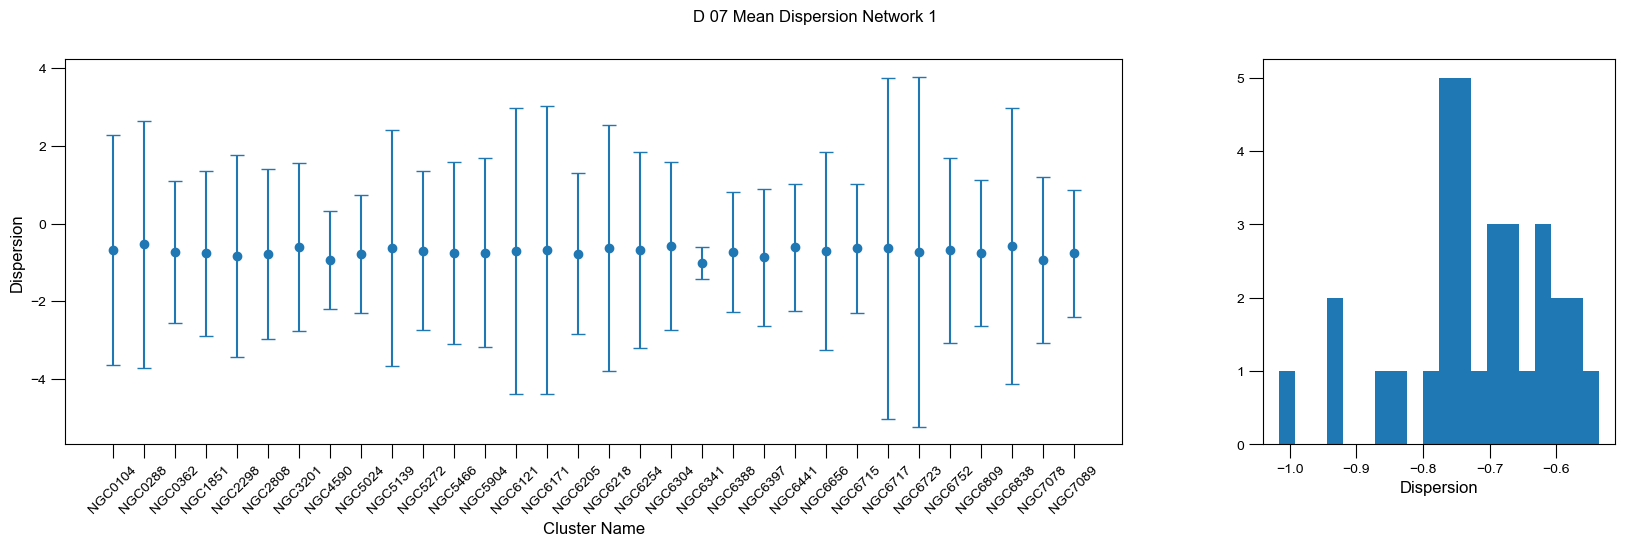

In [183]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [3, 1]})
im = ax1.errorbar(data_gclusters_net1['GlobularCluster_Name'], gcluster_net1_meandisp_d07, yerr=data_gclusters_net1['JM_TESS_Net1_Age']['std'], fmt='o', capsize=5)
ax1.set_xlabel('Cluster Name')
ax1.set_ylabel('Dispersion')
ax1.tick_params(axis='x', rotation=45)
ax2.hist(gcluster_net1_meandisp_d07, bins=20)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('D 07 Mean Dispersion Network 1')

In [184]:
data_gclusters_net2 = g_cluster_stars.groupby('GlobularCluster_Name', as_index=False).agg({
    'JM_TESS_Net2_Age': ['mean', 'std'],
    'Cluster_D07_Age': 'median'})
data_gclusters_net2 = data_gclusters_net2.dropna()
print(data_gclusters_net2)

   GlobularCluster_Name JM_TESS_Net2_Age           Cluster_D07_Age
                                    mean       std          median
0            b'NGC0104'         5.335507  2.897038          12.960
1            b'NGC0288'         6.230955  2.908596          11.880
2            b'NGC0362'         5.180640  1.728677          11.340
3            b'NGC1851'         4.147019  2.132012          10.800
4            b'NGC2298'         5.375041  1.400065          13.635
5            b'NGC2808'         4.762823  2.152371          12.285
6            b'NGC3201'         6.156210  1.229886          11.610
7            b'NGC4590'         3.878097  1.319986          12.015
8            b'NGC5024'         5.548730  1.058035          13.635
9            b'NGC5139'         6.139403  1.838773          12.690
10           b'NGC5272'         6.146087  1.181422          12.960
11           b'NGC5466'         4.870042  1.514069          13.905
12           b'NGC5904'         4.905669  2.090661          11

In [185]:
gcluster_net2_dispersion_d07 = (g_cluster_stars['JM_TESS_Net2_Age'] - g_cluster_stars['Cluster_D07_Age']) / g_cluster_stars['Cluster_D07_Age']
gcluster_net2_meandisp_d07 = (data_gclusters_net2['JM_TESS_Net2_Age']['mean'] - data_gclusters_net2['Cluster_D07_Age']['median']) / data_gclusters_net2['Cluster_D07_Age']['median']

Text(0.5, 0.98, 'D 07 Dispersion Network 2')

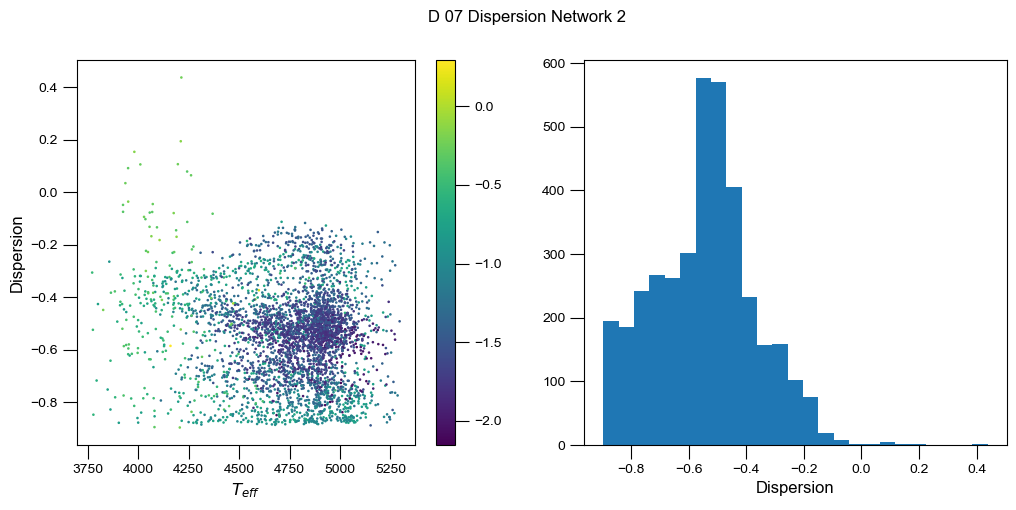

In [186]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.scatter(g_cluster_stars['teff'], gcluster_net2_dispersion_d07, s=0.75, c=g_cluster_stars['fe_h'])
ax1.set_xlabel('$T_{eff}$')
ax1.set_ylabel('Dispersion')
fig.colorbar(im)
ax2.hist(gcluster_net2_dispersion_d07, bins=25)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('D 07 Dispersion Network 2')

Text(0.5, 0.98, 'D 07 Mean Dispersion Network 2')

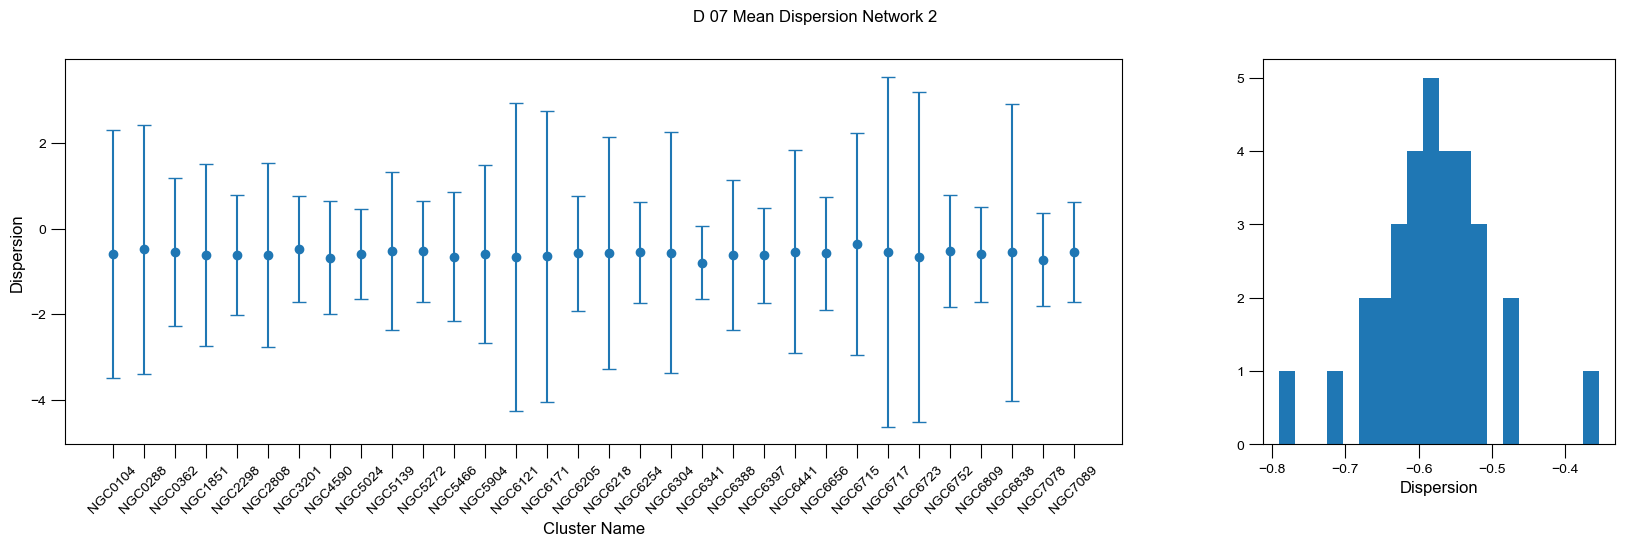

In [189]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [3, 1]})
im = ax1.errorbar(data_gclusters_net2['GlobularCluster_Name'], gcluster_net2_meandisp_d07, yerr=data_gclusters_net2['JM_TESS_Net2_Age']['std'], fmt='o', capsize=5)
ax1.set_xlabel('Cluster Name')
ax1.set_ylabel('Dispersion')
ax1.tick_params(axis='x', rotation=45)
ax2.hist(gcluster_net2_meandisp_d07, bins=20)
ax2.set_xlabel('Dispersion')
fig.align_ylabels()
fig.suptitle('D 07 Mean Dispersion Network 2')